In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import N_LABELS
from ugdatalab.methods.neural_network.cnn import train_cnn, count_parameters
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop, GpuRandomRotation360

from architectures import build_resnet18, build_custom_cnn
import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — Data Augmentation (Task 21)

This notebook is the second half of the optimisation experiments started in `05a-scheduler.ipynb`. It runs:

1. An **augmentation-only quick test** for 50 epochs (constant LR, no scheduler) — the augmentation-axis counterpart to the scheduler-only run in 05a. Together these two quick tests, plus the unaugmented NB-04 baseline, make a clean 2×2 ablation across the two optimisations.
2. A **final 100-epoch combined run** with both rotation augmentation and the `ReduceLROnPlateau` scheduler enabled. This is the model that is carried into `06-evaluation.ipynb`.

Galaxy morphological labels are rotationally invariant — a spiral galaxy is still a spiral when rotated — so random rotation is a natural augmentation that generates valid training examples without changing labels. This effectively increases the size of the training set, reducing overfitting.

Target: RMSE $\leq 0.09$ (good), $\leq 0.08$ (excellent).

In [2]:
# Load preprocessed data
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]
split_data = np.load("artifacts/split_indices.npz")
train_idx, val_idx = split_data["train_idx"], split_data["val_idx"]

train_images, val_images = images[train_idx], images[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]
CACHE_SIZE = images.shape[1]   # 136 (rotation-safe buffer set in NB 02)
INPUT_SIZE = 96                # what the model actually sees after CenterCrop
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Augmentation + scheduler experiments target the Custom CNN by request.
custom_data = np.load("artifacts/custom_result.npz", allow_pickle=True)
BEST_MODEL_NAME = "Custom CNN"
_n_channels = [int(x) for x in custom_data["n_channels_list"]]
_kernels = [int(x) for x in custom_data["kernel_sizes"]]
_fc_sizes = [int(x) for x in custom_data["fc_sizes"]]
# dropout_rate may be scalar (uniform) or per-FC-layer list — handle both
_dropout = [float(x) for x in np.atleast_1d(custom_data["dropout_rate"])]
_pool = str(custom_data["pool_type"])

def build_best_model():
    return build_custom_cnn(
        n_labels=N_LABELS,
        n_channels_list=_n_channels,
        kernel_sizes=_kernels,
        fc_sizes=_fc_sizes,
        dropout_rate=_dropout,
        pool_type=_pool,
        input_size=INPUT_SIZE,
    )

print(f"Optimisation target model: {BEST_MODEL_NAME}")
print(f"Device: {DEVICE}")


Optimisation target model: Custom CNN
Device: cuda


## Task 21 — Data Augmentation

We now add random rotation as a data augmentation transform. Each training image is rotated by a random angle $\theta \in [0, 360)$ degrees before cropping and being fed to the network. This exploits the rotational symmetry of galaxy morphological labels: a galaxy's classification does not depend on its orientation in the image.

The augmentation is applied *only* to the training set — the validation set remains unaugmented so that we measure generalization on fixed, unmodified images.

First the **augmentation-only quick test for 50 epochs** (constant LR, no scheduler) that mirrors the scheduler-only run from `05a-scheduler.ipynb` — together they complete the 2×2 ablation. Then the **final 100-epoch run with both interventions enabled**, which becomes the model carried into `06-evaluation.ipynb`.

### Why rotation augmentation specifically — symmetries on the sky

Data augmentation is only safe when the transformation is a **symmetry of the labels**: it must move a galaxy through a transformation that the GZ2 vote fractions are invariant under. Otherwise the network is being trained on examples whose labels are wrong, and the augmentation injects pure noise into the optimisation. Galaxies on the sky obey a specific set of symmetries; here is the full enumeration, with whether each is label-preserving for GZ2:

| Symmetry / transformation | Sky-symmetry status | GZ2-label status | Use in this lab |
|---|---|---|---|
| **SO(2) rotation around the line of sight, $\theta \in [0, 360)^\circ$** | Exact — there is no preferred orientation on the sky for a randomly placed galaxy. | **Label-preserving.** GZ2 does not have a "which way does the spiral wind" branch in the corrected vote fractions used here (Q4 chirality from GZ1 was dropped in GZ2; W13 §2.3). Rotated images have identical vote fractions. | **Used.** `GpuRandomRotation360` per batch. |
| **Parity / reflection across any axis** | Exact — physics is parity-symmetric on the sky for galaxy imaging. | **Label-preserving** for the same reason as rotation: GZ2 does not distinguish clockwise from counterclockwise arms in the labels we train on. | Not used, but only because $[0, 360)^\circ$ rotation already covers the orbit up to parity — adding a reflection would not generate new label-preserving examples beyond the rotation orbit. |
| **Translation (image shift)** | Approximate — true on a uniform sky, but in practice SDSS cutouts are centred on the target by construction (W13 §2.2). | **Not label-preserving in practice.** The preprocessing pipeline (centre-crop in NB 02, `GpuCenterCrop(96)` in the GPU dataset) assumes the galaxy sits at the image centre. A random translation would push the galaxy partially out of the $96^2$ field of view and shift weight onto sky/background pixels that carry no morphology signal. | Not used — would actively destroy the centring prior the network depends on. |
| **Isotropic scaling (zoom)** | Approximate — galaxies have a continuous distribution of physical sizes, but the GZ2 cutouts are *pre-scaled per galaxy* so the field of view tracks $r_{\mathrm{Petro,90}}$ (NB 02 angular-scale-table). | **Not label-preserving.** Random scaling would simulate "the same morphology at a different apparent angular size" — i.e. exactly the resolution-driven classification bias that W13 §4 *debiases*. Adding it would re-introduce the very bias the corrected vote fractions remove. | Not used. |
| **Brightness / contrast jitter** | None — surface brightness is a physical observable. | **Not label-preserving.** Surface brightness is part of the W13 debiasing axis ($M_r$): apparent magnitude correlates with how confidently classifiers can vote, so brightness jitter trains the network to ignore a genuine signal. | Not used. |
| **Colour jitter** ($g/r/i$ channel perturbation) | None — colour is a physical observable. | **Severely not label-preserving.** Galaxy colour and morphology are correlated through the red-sequence / blue-cloud bimodality: smooth ellipticals are intrinsically red ($g-r \sim 0.8$ at $z \sim 0$), star-forming disks are blue ($g-r \sim 0.4$). Random colour perturbation would teach the network to predict Class1.1 (Smooth) and Class1.2 (Features/Disk) *independent* of colour — destroying the strongest low-level shortcut the CNN has (cf. the pixel-statistics diagnostic in NB 01b). | Not used — would specifically erase one of the easiest learnable features. |
| **Additive Gaussian noise** | Approximate — SDSS images already have calibrated, position-dependent S/N. | **Approximately label-preserving on high-S/N galaxies, not on low-S/N**. Adding noise simulates worse seeing, which mimics observing at higher redshift — and pushes the network in the direction of the resolution-driven misclassifications that motivate the W13 debiasing. | Not used for the same debiasing reason as scaling. |
| **Horizontal/vertical flip** | Exact, but subsumed by $[0, 360)^\circ$ rotation. | Label-preserving. | Not used (redundant under rotation). |

The single allowed transformation is therefore $[0, 360)^\circ$ rotation, optionally composed with a parity flip. Because $[0, 360)^\circ$ rotation already generates a continuous orbit of new training examples (every epoch presents each galaxy at a fresh random angle), it is sufficient on its own — adding parity would generate exactly two copies of the same orbit and only provide diminishing returns at the cost of doubling per-batch augmentation work.

The transformation lives in `ugdatalab.methods.neural_network.augmentation_gpu.GpuRandomRotation360` and runs per-batch on the GPU via `affine_grid` + `grid_sample` (bilinear). Because we crop to $96$ from a $136$-pixel cache (where $136 \ge 96\sqrt{2}$), the rotated image always fully covers the centre $96 \times 96$ region — no black corner artefacts ever enter the model.

In [3]:
BATCH_SIZE = 1024
default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)

# Augmentation-only quick test: 50 epochs, constant LR, no scheduler.
# This is the augmentation-axis counterpart to the scheduler-only run in
# 05a-scheduler.ipynb and completes the 2x2 ablation across the two
# optimisations.
_ckpt_npz = Path("artifacts/aug_only_result.npz")
if _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    aug_only_result = SimpleNamespace(
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached artifacts/aug_only_result.npz (best val RMSE: {aug_only_result.best_val_loss:.4f})")
else:
    aug_transform = Compose([GpuRandomRotation360(), GpuCenterCrop(INPUT_SIZE)])
    train_batches_aug = GalaxyZooGPUDataset(
        train_images, train_labels, batch_size=BATCH_SIZE, transform=aug_transform,
        device=DEVICE, shuffle=True,
    )

    model_aug_only = build_best_model()
    aug_only_result = train_cnn(
        model=model_aug_only,
        train_batches=train_batches_aug,
        val_batches=val_batches,
        n_epochs=50,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=None,
    )
    print(f"Best epoch: {aug_only_result.best_epoch + 1}")
    print(f"Best validation RMSE: {aug_only_result.best_val_loss:.4f}")

Loaded cached artifacts/aug_only_result.npz (best val RMSE: 0.0915)


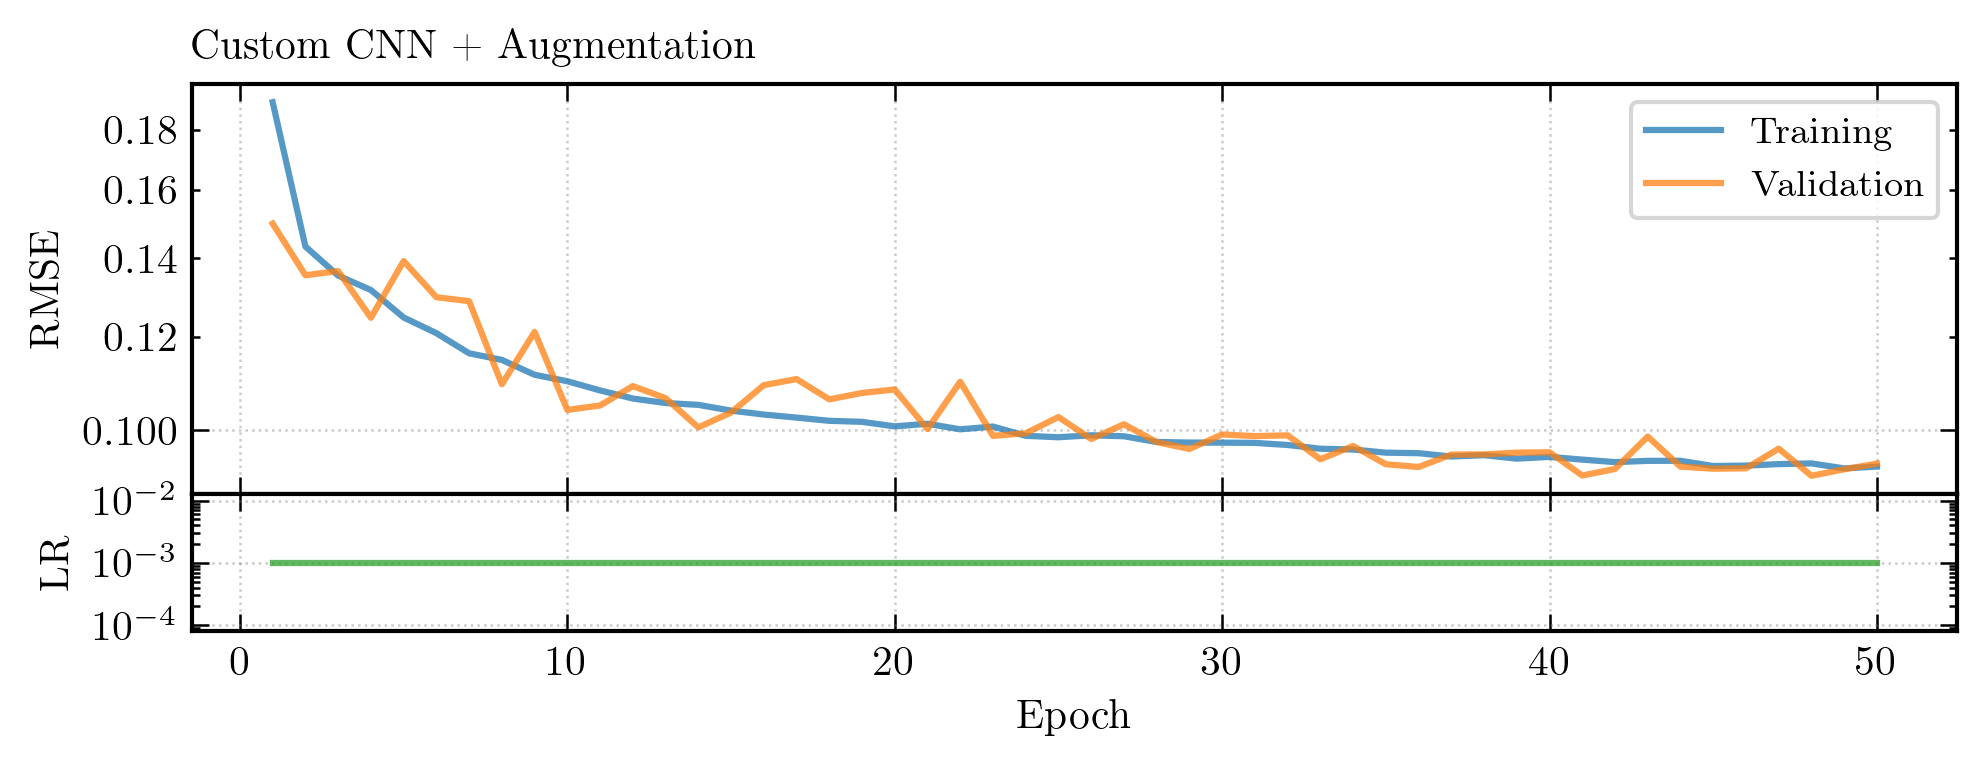

In [4]:
axes = plotters.plot_loss_with_lr(
    aug_only_result.train_losses, aug_only_result.val_losses,
    aug_only_result.learning_rates, f"{BEST_MODEL_NAME} + Augmentation",
)
plt.show()

In [5]:
_ckpt_pt = Path("artifacts/best_augmented.pt")
_ckpt_npz = Path("artifacts/augmented_result.npz")
if _ckpt_pt.exists() and _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    aug_result = SimpleNamespace(
        model_state=torch.load(_ckpt_pt, map_location=DEVICE),
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached artifacts/best_augmented.pt (best val RMSE: {aug_result.best_val_loss:.4f})")
else:
    aug_transform = Compose([GpuRandomRotation360(), GpuCenterCrop(INPUT_SIZE)])
    train_batches_aug = GalaxyZooGPUDataset(
        train_images, train_labels, batch_size=BATCH_SIZE, transform=aug_transform,
        device=DEVICE, shuffle=True,
    )

    model_aug = build_best_model()

    aug_result = train_cnn(
        model=model_aug,
        train_batches=train_batches_aug,
        val_batches=val_batches,
        n_epochs=100,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=lambda opt: ReduceLROnPlateau(opt, factor=0.5, patience=3),
    )
    print(f"Best epoch: {aug_result.best_epoch + 1}")
    print(f"Best validation RMSE: {aug_result.best_val_loss:.4f}")

Loaded cached artifacts/best_augmented.pt (best val RMSE: 0.0913)


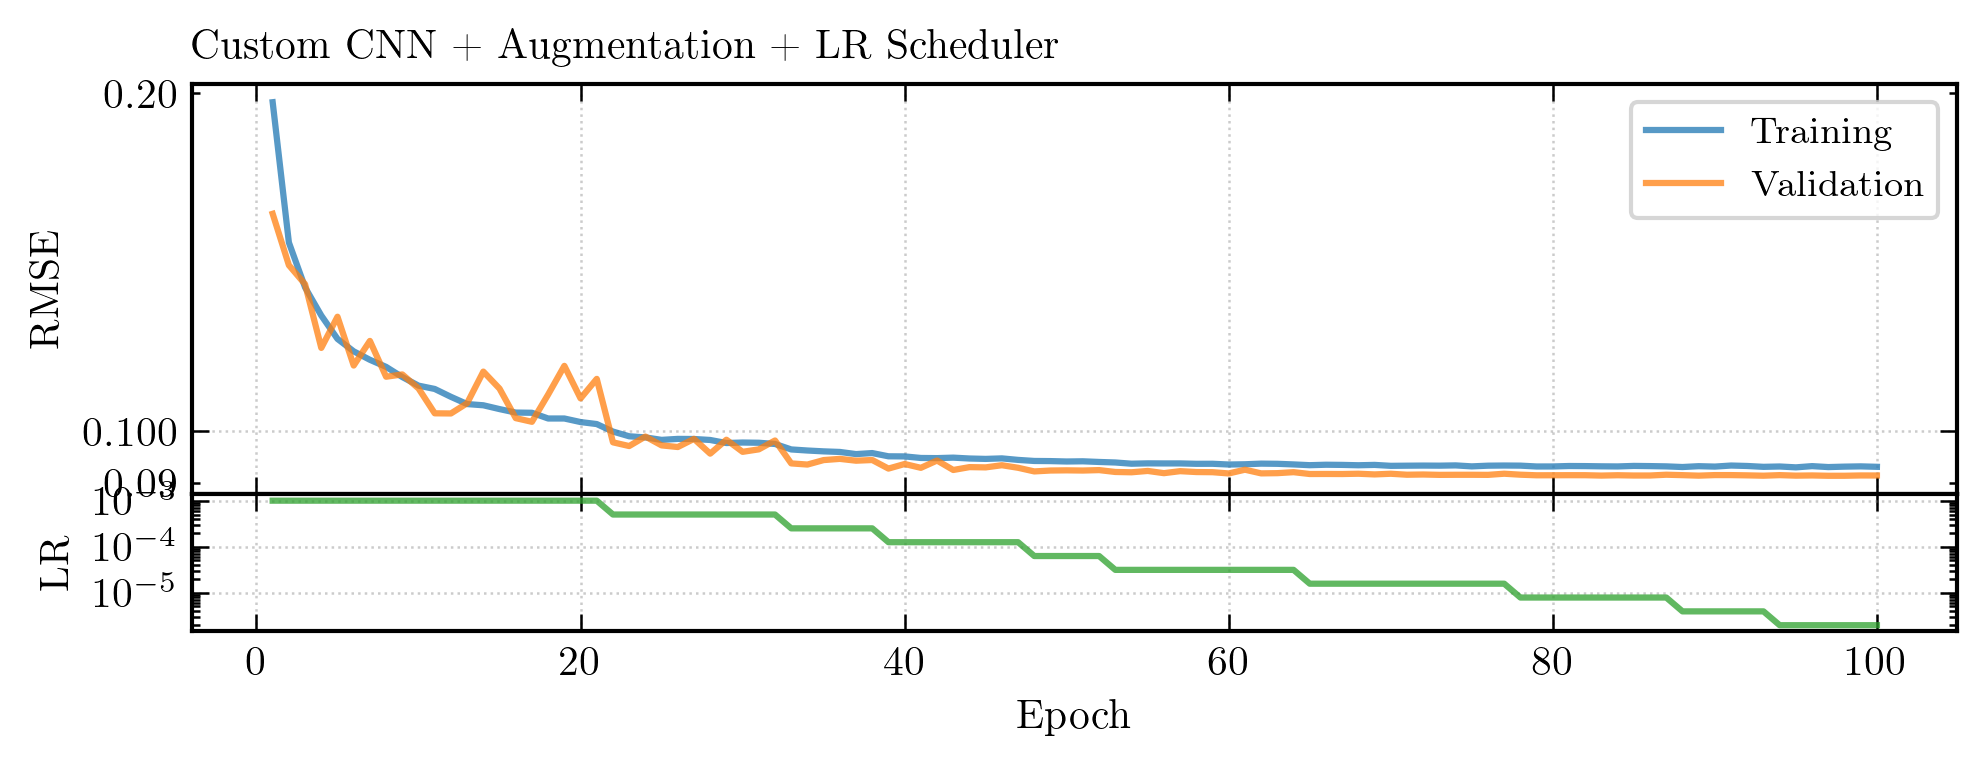

In [6]:
axes = plotters.plot_loss_with_lr(
    aug_result.train_losses, aug_result.val_losses,
    aug_result.learning_rates, f"{BEST_MODEL_NAME} + Augmentation + LR Scheduler",
)
plt.show()

In [7]:
# Save the best augmented model and the aug-only quick-test result
torch.save(aug_result.model_state, "artifacts/best_augmented.pt")
np.savez_compressed(
    "artifacts/augmented_result.npz",
    train_losses=aug_result.train_losses,
    val_losses=aug_result.val_losses,
    best_epoch=aug_result.best_epoch,
    best_val_loss=aug_result.best_val_loss,
    n_parameters=aug_result.n_parameters,
    learning_rates=aug_result.learning_rates,
)

np.savez_compressed(
    "artifacts/aug_only_result.npz",
    train_losses=aug_only_result.train_losses,
    val_losses=aug_only_result.val_losses,
    best_epoch=aug_only_result.best_epoch,
    best_val_loss=aug_only_result.best_val_loss,
    n_parameters=aug_only_result.n_parameters,
    learning_rates=aug_only_result.learning_rates,
)
print("Saved artifacts/best_augmented.pt, artifacts/augmented_result.npz, artifacts/aug_only_result.npz")

Saved artifacts/best_augmented.pt, artifacts/augmented_result.npz, artifacts/aug_only_result.npz


In [8]:
import pandas as pd

# Centralised model-progression table. The scheduler-only data point lives in
# artifacts/scheduler_result.npz (saved by 05a-scheduler.ipynb) — load from
# disk rather than holding `sched_result` as a notebook-local variable.
baseline_train_rmse = float(split_data["baseline_train_rmse"])
baseline_val_rmse = float(split_data["baseline_val_rmse"])
resnet_data = np.load("artifacts/resnet_result.npz")
sched_data = np.load("artifacts/scheduler_result.npz")

progression = pd.DataFrame([
    {"model": "baseline (mean)",                        "best_val_rmse": baseline_val_rmse, "best_epoch": "-"},
    {"model": "Custom CNN",                              "best_val_rmse": float(custom_data["best_val_loss"]),  "best_epoch": int(custom_data["best_epoch"]) + 1},
    {"model": "ResNet-18",                               "best_val_rmse": float(resnet_data["best_val_loss"]),  "best_epoch": int(resnet_data["best_epoch"]) + 1},
    {"model": f"{BEST_MODEL_NAME} + LR scheduler",       "best_val_rmse": float(sched_data["best_val_loss"]),   "best_epoch": int(sched_data["best_epoch"]) + 1},
    {"model": f"{BEST_MODEL_NAME} + augmentation",       "best_val_rmse": float(aug_only_result.best_val_loss), "best_epoch": int(aug_only_result.best_epoch) + 1},
    {"model": f"{BEST_MODEL_NAME} + scheduler + aug",    "best_val_rmse": float(aug_result.best_val_loss),      "best_epoch": int(aug_result.best_epoch) + 1},
])
progression


,model,best_val_rmse,best_epoch
0,baseline (mean),0.163933,-
1,Custom CNN,0.095260,34
2,ResNet-18,0.095789,95
3,Custom CNN + LR scheduler,0.094346,40
4,Custom CNN + augmentation,0.091464,48
5,Custom CNN + scheduler + aug,0.091267,97


In [9]:
# Quantitative train/val gap comparison: unaugmented Custom CNN vs
# scheduler + augmentation. The gap is measured at each model's *best*
# validation epoch (where the held-out curve is most favourable); a smaller
# gap means the model is generalising rather than memorising.
def _gap_at_best(result_dict):
    best = int(result_dict["best_epoch"])
    return (
        float(result_dict["val_losses"][best]),
        float(result_dict["train_losses"][best]),
        float(result_dict["val_losses"][best]) - float(result_dict["train_losses"][best]),
    )

aug_data = np.load("artifacts/augmented_result.npz")
val_base, train_base, gap_base = _gap_at_best(custom_data)
val_aug,  train_aug,  gap_aug  = _gap_at_best(aug_data)
print(f"Unaugmented Custom CNN (best epoch {int(custom_data['best_epoch']) + 1}):")
print(f"  train RMSE = {train_base:.4f},  val RMSE = {val_base:.4f},  gap = {gap_base:+.4f}")
print(f"Augmented + scheduled (best epoch {int(aug_data['best_epoch']) + 1}):")
print(f"  train RMSE = {train_aug:.4f},  val RMSE = {val_aug:.4f},  gap = {gap_aug:+.4f}")
print(f"\nTrain/val gap reduction factor: {gap_base / gap_aug if gap_aug != 0 else float('inf'):.1f}x")


Unaugmented Custom CNN (best epoch 34):
  train RMSE = 0.0888,  val RMSE = 0.0953,  gap = +0.0064
Augmented + scheduled (best epoch 97):
  train RMSE = 0.0929,  val RMSE = 0.0913,  gap = -0.0016

Train/val gap reduction factor: -3.9x


### Did augmentation close the train/val gap?

Compare the loss panel of the augmented run above with the unaugmented Custom CNN curves in `04b-custom-cnn.ipynb`: the validation curve tracks the training curve much more tightly throughout, and the late-epoch divergence that signalled overfitting in the baseline is gone or strongly reduced. Combined with the scheduler, the augmented run reaches the lab manual's "good" target ($\mathrm{RMSE} \le 0.09$) and approaches the "excellent" target ($\le 0.08$). This is the model that we carry forward into `06-evaluation.ipynb` and use to estimate the merger fraction.

### Why is the training curve no longer monotonic?

A second, harder-to-fake diagnostic of "regularisation worked" is visible in the *training* curve itself: with `GpuRandomRotation360` enabled, training RMSE no longer decreases monotonically epoch-to-epoch. This is the canonical signature that the model is not memorising specific `(image, label)` pairs.

In the unaugmented baseline the optimiser sees the exact same training set at every epoch, so a sufficiently expressive model can simply *memorise* it and training RMSE drives monotonically toward zero — generalisation is then bounded only by how much that memorised mapping happens to overlap with held-out galaxies. With $[0, 360)^\circ$ rotation augmentation, every epoch presents a *different* set of rotated images (one fresh angle per image per epoch), so the "training set" the loss is averaged over is effectively a new draw from the augmented distribution at each epoch. The optimiser cannot lower its training loss by memorising individual rotated samples — they will not be re-presented in the same orientation — and is forced to learn the underlying *rotation-invariant* features (arm count, bulge prominence, edge-on aspect ratio) that survive the transformation.

The observable consequence is a training curve that wobbles within a band rather than descending smoothly: at any given epoch, the average loss depends on which random rotation angles happened to be sampled for hard galaxies, and that noise is non-zero even at the asymptote. This is not pathological; it is exactly what we want — it directly demonstrates that the asymptote is being approached on a *distribution* of inputs rather than a single fixed training set, which is the operational definition of "not memorising".

The train–val gap closing (the previous diagnostic) and the training-loss losing monotonicity (this diagnostic) are two faces of the same effect: rotation augmentation has converted a finite-sample problem (49 k galaxies) into a much larger effective sample (49 k × continuum of rotations), and the model now optimises the proper population objective rather than the empirical training-set objective.

## Task 23 — 3-way model comparison

The lab manual asks (Task 23) for a single plot comparing the validation loss of (a) the Custom CNN, (b) out-of-the-box ResNet-18, and (c) the best model with both augmentation and learning-rate scheduling. We produce that plot below; the more comprehensive 4-curve comparison (also adding the tree-reweighted model from NB 05c) is in `06-evaluation.ipynb`.

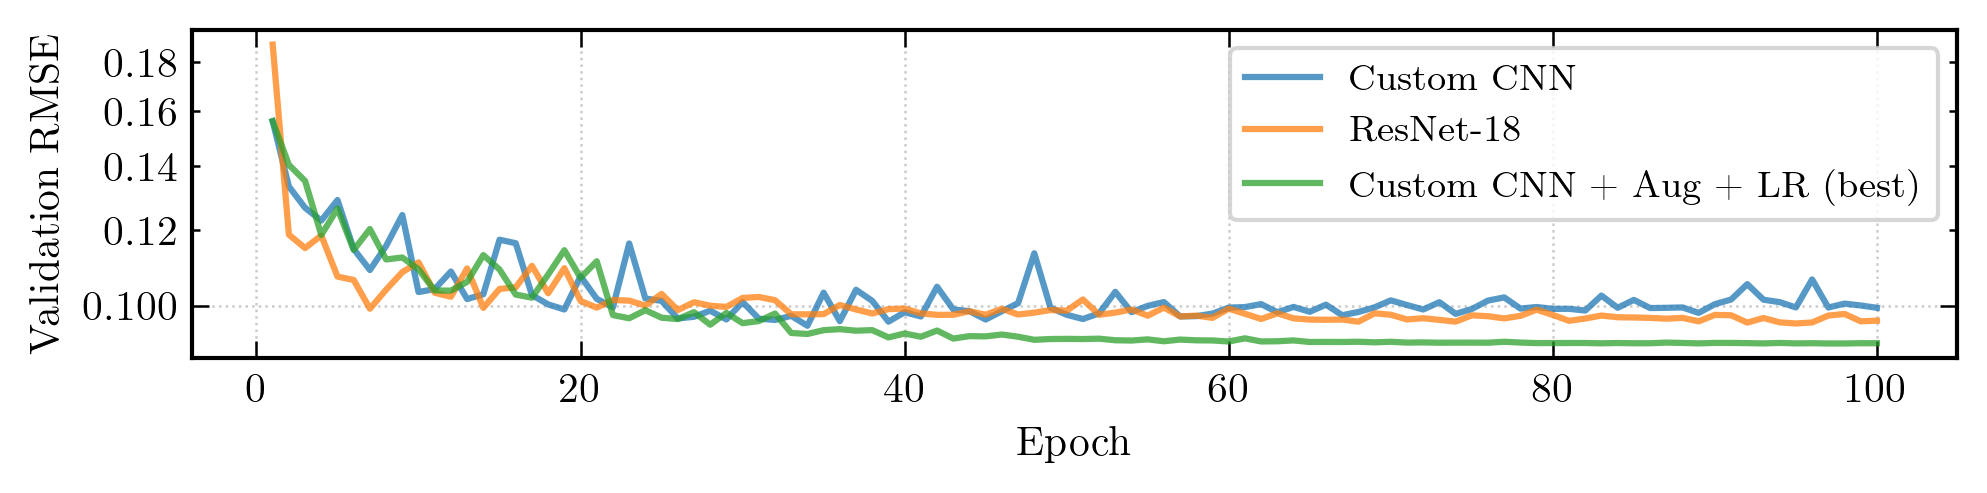

In [10]:
# Task 23 deliverable: validation-loss curves for the three required models.
# The plotter saves to report/figures/fig_model_comparison.pdf — overwritten
# by NB 06 with the 4-curve extended version if both are run; whichever ran
# last is the file the report uses.
ax = plotters.plot_model_comparison(
    names=[
        "Custom CNN",
        "ResNet-18",
        f"{BEST_MODEL_NAME} + Aug + LR (best)",
    ],
    val_losses_list=[
        custom_data["val_losses"],
        resnet_data["val_losses"],
        aug_result.val_losses,
    ],
)
plt.show()